### Name: Aryan Kapri
### Student ID: 398551

### Skill 1: Analytic question formulation

#### During the FIFA World Cup 2026, do teams with higher possession achieve better shooting accuracy than their lower-possession opponents, and what is the average difference in shooting accuracy?

This investigates whether controlling the ball actually helps a team make its shots more accurate, rather than simply taking more shots. A team might dominate possession but still waste its chances.

Shooting accuracy is the percentage of a team’s total shots that are on target:

`Shooting Accuracy = Total Shots / Shots on Target × 100`



### Skill 2: Data Wrangling

#### Importing Libraries and Loading Dataset

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
pd.set_option("display.max_columns", None)

In [6]:
def find_csv(name):
    matches_found = glob.glob(f"**/{name}", recursive=True)
    return matches_found[0] if matches_found else name


matches  = pd.read_csv(find_csv("matches.csv"))
match_stats   = pd.read_csv(find_csv("match_team_stats.csv"))

for name, df in [
    ("matches", matches),
    ("match_stats", match_stats),
]:
    print(f"{name:<12} -> {df.shape[0]:>5} rows x {df.shape[1]:>2} cols") # Checking the shape of the data

matches      ->   104 rows x 17 cols
match_stats  ->   208 rows x 12 cols


In [7]:
matches.head()

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,home_penalty_score,away_penalty_score,status,result_type,home_xg,away_xg,referee_id,player_of_the_match_id
0,1,2026-06-11,19:00,1,1,1,2,2,0,NaN,NaN,Completed,Regular,1.84,0.52,2,16
1,2,2026-06-11,23:00,1,7,3,4,2,1,NaN,NaN,Completed,Regular,1.45,1.12,9,58
2,3,2026-06-12,19:00,1,6,5,6,1,1,NaN,NaN,Completed,Regular,1.35,0.98,11,112
3,4,2026-06-12,23:00,1,3,13,14,4,1,NaN,NaN,Completed,Regular,2.76,0.88,12,332
4,5,2026-06-13,15:00,1,15,7,8,1,1,NaN,NaN,Completed,Regular,0.78,1.54,15,157


In [8]:
match_stats.head()

,match_id,team_id,possession_pct,total_shots,shots_on_target,corners,fouls,offsides,saves,player_of_the_match,data_source,last_updated
0,1,1,57,16,4,6,11,2,1,Julián Andrés Quinones,fifa.com,2026-06-24
1,1,2,43,3,2,3,15,1,4,NaN,fifa.com,2026-06-24
2,2,3,54,12,5,4,10,1,2,Inbeom Hwang,sofascore.com,2026-06-24
3,2,4,46,10,3,3,13,2,4,NaN,sofascore.com,2026-06-24
4,3,5,52,13,4,9,12,2,3,Ismaël Kenneth Jordan Kone,fifa.com,2026-06-24


In [10]:
print("\nMatch stats columns:")
print(match_stats.columns.tolist())

print("\nMatches columns:")
print(matches.columns.tolist())


Match statistics columns:
['match_id', 'team_id', 'possession_pct', 'total_shots', 'shots_on_target', 'corners', 'fouls', 'offsides', 'saves', 'player_of_the_match', 'data_source', 'last_updated']

Matches columns:
['match_id', 'date', 'kickoff_time_utc', 'stage_id', 'venue_id', 'home_team_id', 'away_team_id', 'home_score', 'away_score', 'home_penalty_score', 'away_penalty_score', 'status', 'result_type', 'home_xg', 'away_xg', 'referee_id', 'player_of_the_match_id']


In [11]:
print("\nMatch stats information:")
match_stats.info()

print("\nMatches information:")
matches.info()


Match statistics information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             208 non-null    int64 
 1   team_id              208 non-null    int64 
 2   possession_pct       208 non-null    int64 
 3   total_shots          208 non-null    int64 
 4   shots_on_target      208 non-null    int64 
 5   corners              208 non-null    int64 
 6   fouls                208 non-null    int64 
 7   offsides             208 non-null    int64 
 8   saves                208 non-null    int64 
 9   player_of_the_match  104 non-null    object
 10  data_source          208 non-null    object
 11  last_updated         208 non-null    object
dtypes: int64(9), object(3)
memory usage: 19.6+ KB

Matches information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 17 columns):


In [12]:
required_cols = ["match_id","team_id","possession_pct","total_shots","shots_on_target"] # Columns for our analysis

print("Missing values in required columns:")
print(match_stats[required_cols].isna().sum())

Missing values in required columns:
match_id           0
team_id            0
possession_pct     0
total_shots        0
shots_on_target    0
dtype: int64


In [13]:
print("\nDuplicate match-team records:")
print(match_stats.duplicated(subset=["match_id", "team_id"]).sum())


Duplicate match-team records:
0


In [14]:
print("\nNumber of team records per match:")
print(match_stats.groupby("match_id").size().value_counts().sort_index())


Number of team records per match:
2    104
Name: count, dtype: int64


In [15]:
print("\nMissing match IDs in matches:")
print(matches["match_id"].isna().sum())


Missing match IDs in matches:
0


In [16]:
print("\nDuplicate match IDs in matches:")
print(matches["match_id"].duplicated().sum())


Duplicate match IDs in matches:
0


In [19]:
# Select only the columns needed for our investigation, using copy method not to alter the original dataset
stats_selected = match_stats[["match_id", "team_id", "possession_pct","total_shots", "shots_on_target"]].copy()
matches_selected = matches[["match_id", "date", "stage_id", "status","home_team_id", "away_team_id"]].copy()

assert not stats_selected.duplicated(subset=["match_id", "team_id"]).any(), "Duplicate match-team records found!"
assert matches_selected["match_id"].is_unique, \
    "Duplicate match IDs found!"

# Performing left join using shared column match_id
merged = stats_selected.merge(
    matches_selected,
    on="match_id",
    how="left",
    validate="many_to_one",
    indicator=True
)

print("Merge results:")
print(merged["_merge"].value_counts())
print("\nMerged dataset shape:")
print(merged.shape)

display(merged.head())

Merge results:
_merge
both          208
left_only       0
right_only      0
Name: count, dtype: int64

Merged dataset shape:
(208, 11)


,match_id,team_id,possession_pct,total_shots,shots_on_target,date,stage_id,status,home_team_id,away_team_id,_merge
0,1,1,57,16,4,2026-06-11,1,Completed,1,2,both
1,1,2,43,3,2,2026-06-11,1,Completed,1,2,both
2,2,3,54,12,5,2026-06-11,1,Completed,3,4,both
3,2,4,46,10,3,2026-06-11,1,Completed,3,4,both
4,3,5,52,13,4,2026-06-12,1,Completed,5,6,both


In [20]:
analysis = merged.drop(columns="_merge").copy()
invalid = analysis[
    (analysis["possession_pct"] < 0) |
    (analysis["possession_pct"] > 100) |
    (analysis["total_shots"] < 0) |
    (analysis["shots_on_target"] < 0) |
    (analysis["shots_on_target"] > analysis["total_shots"])
]

print("Number of records with invalid values:", len(invalid))
display(invalid)

Number of records with invalid values: 0


,match_id,team_id,possession_pct,total_shots,shots_on_target,date,stage_id,status,home_team_id,away_team_id


In [21]:
print("\nRecords with zero total shots:")
print((analysis["total_shots"] == 0).sum())

# Calculating shooting accuracy, and zero-shot records remain undefined rather than being assigned 0%
analysis["shooting_accuracy"] = np.where(analysis["total_shots"] > 0,analysis["shots_on_target"] / analysis["total_shots"] * 100,np.nan)


Records with zero total shots:
0


In [22]:
display(analysis[["match_id", "team_id", "possession_pct","total_shots", "shots_on_target", "shooting_accuracy"]].head(10)) # Checking the new variable

print("\nShooting accuracy summary:")
print(analysis["shooting_accuracy"].describe())

,match_id,team_id,possession_pct,total_shots,shots_on_target,shooting_accuracy
0,1,1,57,16,4,25.000000
1,1,2,43,3,2,66.666667
2,2,3,54,12,5,41.666667
3,2,4,46,10,3,30.000000
4,3,5,52,13,4,30.769231
5,3,6,29,8,3,37.500000
6,4,13,59,16,6,37.500000
7,4,14,28,9,1,11.111111
8,5,7,28,6,3,50.000000
9,5,8,58,26,7,26.923077



Shooting accuracy summary:
count    208.000000
mean      34.640107
std       14.598234
min        0.000000
25%       25.000000
50%       33.333333
75%       43.750000
max       83.333333
Name: shooting_accuracy, dtype: float64


In [24]:
eligible = analysis.groupby("match_id").filter(lambda x: x["possession_pct"].nunique() == 2).copy() # Remove matches where both teams have equal possession
eligible = eligible.sort_values(["match_id", "possession_pct"],ascending=[True, False]) # Sort higher-possession team first

match_pairs = eligible.groupby("match_id").agg(
    accuracy_high=("shooting_accuracy", "first"),
    accuracy_low=("shooting_accuracy", "last"),
    possession_high=("possession_pct", "first"),
    possession_low=("possession_pct", "last")
).reset_index() # Putting both opponents into one row


match_pairs["accuracy_difference"] = (match_pairs["accuracy_high"] - match_pairs["accuracy_low"]) # Calculating the difference in percentage points

print("Number of eligible matches:", len(match_pairs))
display(match_pairs.head())

Number of eligible matches: 101


,match_id,accuracy_high,accuracy_low,possession_high,possession_low,accuracy_difference
0,1,25.000000,66.666667,57,43,-41.666667
1,2,41.666667,30.000000,54,46,11.666667
2,3,30.769231,37.500000,52,29,-6.730769
3,4,37.500000,11.111111,59,28,26.388889
4,5,26.923077,50.000000,58,28,-23.076923


#### `Skill 2 Summary:` 

I first checked the two datasets for missing values, duplicate identifiers and data types. All five required variables were complete, and each of the 104 matches had two team records. I then used a left join on match_id, which successfully matched all 208 team-statistic records without changing the row count.

Next, I calculated shooting accuracy using shots on target divided by total shots, multiplied by 100. I found no invalid values or zero-shot records. Finally, I excluded three equal-possession matches because neither team could be classified as having higher possession. This left 101 match pairs, with one accuracy difference per match.

### Skill 3: Data preparation and sampling

In [25]:
sample = match_pairs.sample(
    n=40,
    replace=False,
    random_state=42 #it takes the same sample everytime we execute this block of code, it helps so that the output doesnt alter on every execution
).copy()

print("Population size:", len(match_pairs))
print("Sample size:", len(sample))
print("Unique matches:", sample["match_id"].nunique())
display(sample.head(10))

Population size: 101
Sample size: 40
Unique matches: 40


,match_id,accuracy_high,accuracy_low,possession_high,possession_low,accuracy_difference
84,87,50.000000,31.250000,64,36,18.750000
55,57,43.750000,45.454545,56,44,-1.704545
66,69,25.000000,15.384615,55,45,9.615385
67,70,21.052632,33.333333,64,36,-12.280702
45,46,28.571429,25.000000,58,42,3.571429
39,40,41.176471,33.333333,65,35,7.843137
22,23,36.363636,28.571429,55,35,7.792208
44,45,44.444444,20.000000,62,38,24.444444
10,11,8.333333,26.666667,49,41,-18.333333
0,1,25.000000,66.666667,57,43,-41.666667


#### `Skill 3 Summary:`

`Population:` The 101 eligible matches in the uploaded World Cup 2026 dataset. Both teams had to take at least one shot, and one team had to record higher possession.

`Sampling frame:` The 101 unique match IDs in match_pairs, after the three equal-possession matches were excluded.

`Unit of observation:` One match. Each row contains both opponents' shooting accuracy and the difference between them.

`Sample:` I selected 40 matches using simple random sampling without replacement. The fixed seed, random_state=42, makes the selection reproducible. Each eligible match had an equal chance of being selected.

`Parameter of interest:` μD, the mean accuracy difference across the 101 eligible matches, measured in percentage points.

The sample gives us a practical way to estimate the population mean. Still, 40 matches make up a large part of the population, so I also consider the finite population correction in the inferential analysis. I use the same sample for all the remaining skills.

### Skill 4: Descriptive statistics

In [26]:
difference = sample["accuracy_difference"]
print("Accuracy difference summary:")
display(difference.describe())

print("Median:", difference.median())
print("Skewness:", difference.skew())
print("\nMean accuracy by possession group:") # Comparing two possession groups
print("Higher possession:", sample["accuracy_high"].mean())
print("Lower possession:", sample["accuracy_low"].mean())

Accuracy difference summary:


count    40.000000
mean      2.840374
std      24.189494
min     -58.333333
25%     -12.447133
50%       3.774351
75%      19.642857
max      42.857143
Name: accuracy_difference, dtype: float64

Median: 3.77435064935065
Skewness: -0.6069894986158156

Mean accuracy by possession group:
Higher possession: 34.386221317783864
Lower possession: 31.5458476744274


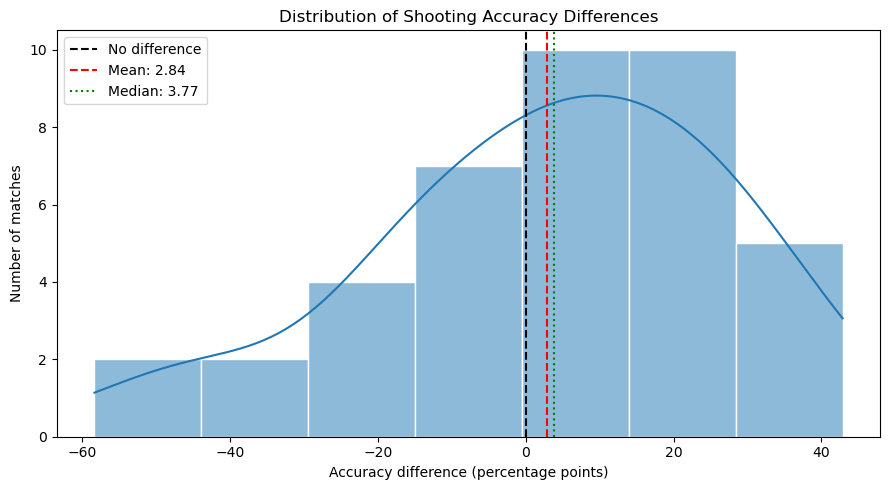

In [27]:
plt.figure(figsize=(9, 5))

sns.histplot(difference,bins="auto",kde=True,edgecolor="white")

plt.axvline(0, color="black", linestyle="--", label="No difference")
plt.axvline(difference.mean(), color="red", linestyle="--", label=f"Mean: {difference.mean():.2f}")
plt.axvline(difference.median(), color="green", linestyle=":", label=f"Median: {difference.median():.2f}")
plt.title("Distribution of Shooting Accuracy Differences")
plt.xlabel("Accuracy difference (percentage points)")
plt.ylabel("Number of matches")
plt.legend()
plt.tight_layout()
plt.show()

The histogram shows a wide spread of accuracy differences, with observations on both sides of zero. The mean is +2.84 percentage points and the median is +3.77, so the sample has a small advantage for higher-possession teams. Still, the longer negative tail shows that lower-possession teams were much more accurate in some matches. The skewness of −0.61 supports this pattern.

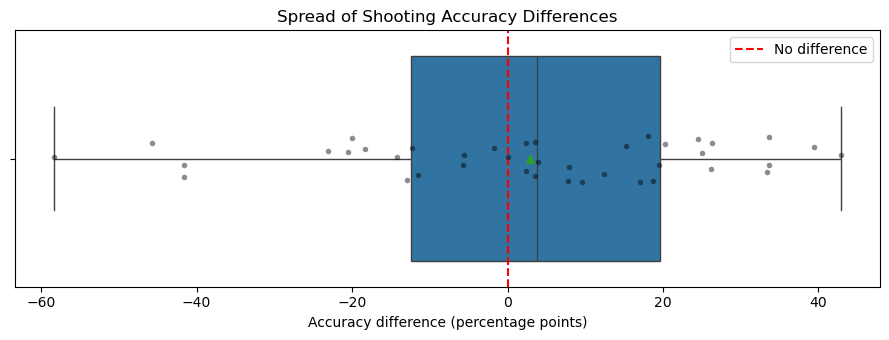

In [28]:
plt.figure(figsize=(9, 3.5))

sns.boxplot(x=difference, showmeans=True)
sns.stripplot(x=difference, color="black", alpha=0.45, size=4)

plt.axvline(0, color="red", linestyle="--", label="No difference")
plt.title("Spread of Shooting Accuracy Differences")
plt.xlabel("Accuracy difference (percentage points)")
plt.legend()
plt.tight_layout()
plt.show()

The middle 50% of the differences lie between about −12.5 and +19.6 percentage points. The box crosses zero, which shows that either group can perform better. The full range is wide, from −58.3 to +42.8. No clear outliers appear beyond the whiskers, so I haven't removed any observations. The main point is that shooting accuracy varies considerably between matches.

#### `Skills 4 Summary:` 

The histogram and boxplot helped explain this variation. They show a slight positive tendency, but also several matches where the lower-possession team was more accurate. These results answer the descriptive part of the question. We now need a confidence interval and hypothesis test to assess how much uncertainty surrounds the estimated population mean.

### Skill 5: Inferential statistics: Confidence interval

In [29]:
from scipy import stats

In [30]:
difference = sample["accuracy_difference"]

n = len(difference)
N = len(match_pairs)
mean_diff = difference.mean()
sd = difference.std(ddof=1)

In [31]:
se = sd / np.sqrt(n) 
t_critical = stats.t.ppf(0.975, df=n - 1)

margin = t_critical * se
ci_standard = (mean_diff - margin, mean_diff + margin)

fpc = np.sqrt((N - n) / (N - 1)) # Finite population correction
se_finite = se * fpc
margin_finite = t_critical * se_finite
ci_finite = (mean_diff - margin_finite, mean_diff + margin_finite)

print(f"Population size (N): {N}")
print(f"Sample size (n): {n}")
print(f"Sample mean: {mean_diff:.4f} percentage points")
print(f"Sample standard deviation: {sd:.4f}")
print(f"Standard error: {se:.4f}")
print(f"t critical value: {t_critical:.4f}")

print(f"\nStandard 95% CI: ({ci_standard[0]:.2f}, {ci_standard[1]:.2f})")
print(f"Finite-population 95% CI: ({ci_finite[0]:.2f}, {ci_finite[1]:.2f})")

Population size (N): 101
Sample size (n): 40
Sample mean: 2.8404 percentage points
Sample standard deviation: 24.1895
Standard error: 3.8247
t critical value: 2.0227

Standard 95% CI: (-4.90, 10.58)
Finite-population 95% CI: (-3.20, 8.88)


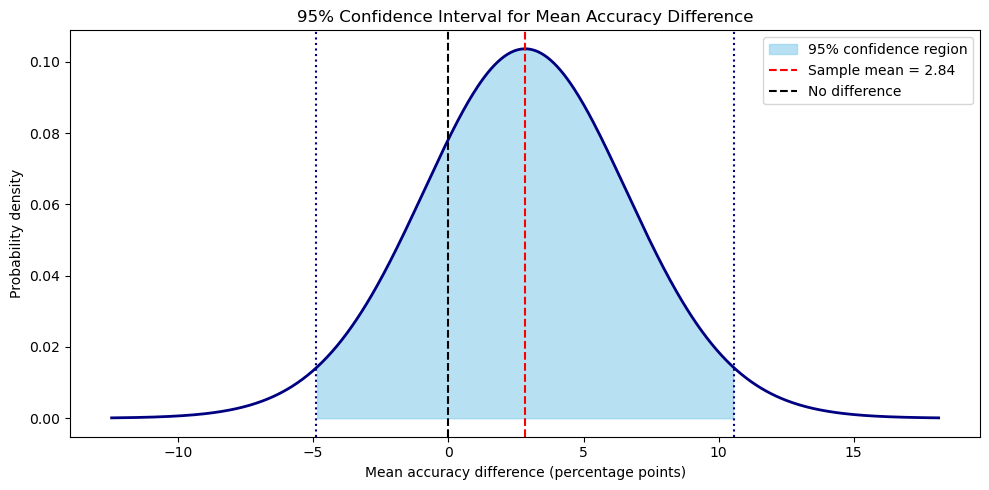

In [33]:
x = np.linspace(mean_diff - 4*se, mean_diff + 4*se, 500)
y = stats.t.pdf((x - mean_diff) / se, df=n-1) / se

plt.figure(figsize=(10, 5))
plt.plot(x, y, color="navy", linewidth=2)
plt.fill_between(x, y,where=(x >= ci_standard[0]) & (x <= ci_standard[1]),color="skyblue",alpha=0.6,label="95% confidence region") #shading the 95%


plt.axvline(mean_diff, color="red", linestyle="--",label=f"Sample mean = {mean_diff:.2f}") # Marking mean, interval boundaries, and zero
plt.axvline(ci_standard[0], color="navy", linestyle=":")
plt.axvline(ci_standard[1], color="navy", linestyle=":")
plt.axvline(0, color="black", linestyle="--", label="No difference")
plt.title("95% Confidence Interval for Mean Accuracy Difference")
plt.xlabel("Mean accuracy difference (percentage points)")
plt.ylabel("Probability density")
plt.legend()
plt.tight_layout()
plt.show()

The sample mean was +2.84 percentage points. The standard 95% confidence interval ranged from approximately −4.90 to +10.5 percentage points. After applying the finite population correction, the interval narrowed to about −3.2 to +8.8.

Both intervals include zero. This means the data is compatible with a small advantage for either group, as well as no average difference. The sample points towards a slight higher-possession advantage, but the estimate is too uncertain to establish a clear population difference. This gives us a useful reason to examine the result with a hypothesis test. Hence, lets move to the one sample t-test.

#### `Skill 5 Summary:` 

I used the same 40 matches to estimate the population mean accuracy difference. Because the population standard deviation was unknown, I calculated a 95% t-based confidence interval. The standard interval was approximately −4.9 to +10.5 percentage points. I also applied a finite population correction because the sample contained 40 of the 101 eligible matches.

The bell-curve graph illustrates the estimated sampling distribution of the mean and the standard confidence limits. The shaded area is not the distribution of individual match differences, and it doesn't mean there is a 95% probability that the fixed population mean lies inside the interval. Both calculated intervals contain zero, so we can't yet establish a clear average advantage.

### Skill 6: Inferential statistics: One-sample t-test

In [34]:
difference = sample["accuracy_difference"]
alpha = 0.05

t_stat, p_value = stats.ttest_1samp(difference, popmean=0, alternative="two-sided") # Standard one sample t-test

print("STANDARD ONE-SAMPLE T-TEST")
print(f"Sample size: {len(difference)}")
print(f"Mean difference: {difference.mean():.4f} pp")
print(f"t-statistic: {t_stat:.4f}")
print(f"Degrees of freedom: {len(difference) - 1}")
print(f"p-value: {p_value:.4f}")

if p_value < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")

STANDARD ONE-SAMPLE T-TEST
Sample size: 40
Mean difference: 2.8404 pp
t-statistic: 0.7426
Degrees of freedom: 39
p-value: 0.4621
Decision: Fail to reject H0


In [35]:
N = len(match_pairs) # Finite population adjusted approximation
n = len(difference)

fpc = np.sqrt((N - n) / (N - 1))
t_finite = t_stat / fpc
p_finite = 2 * stats.t.sf(abs(t_finite), df=n - 1)

print("\nFINITE-POPULATION-ADJUSTED TEST")
print(f"Adjusted t-statistic: {t_finite:.4f}")
print(f"Approximate p-value: {p_finite:.4f}")

if p_finite < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")


FINITE-POPULATION-ADJUSTED TEST
Adjusted t-statistic: 0.9509
Approximate p-value: 0.3475
Decision: Fail to reject H0


#### `Skill 6 Summary:`

The standard p-value is 0.4621, which is much greater than 0.05. If the true average difference were zero, a result at least as extreme as ours would I used a two-sided one-sample t-test to check whether the mean shooting accuracy difference was different from zero. 

The test gave t(39) = 0.7426 and p = 0.4621. Since the p-value was greater than 0.05, I failed to reject the null hypothesis. The finite-population-adjusted result was also non-significant (p = 0.3475). This agrees with the confidence interval, which included zero. The results don't prove that both groups have identical accuracy, but they don't provide enough evidence to establish a population mean difference.

### Conclusion:

Our analytical question investigated whether teams with higher possession achieved better shooting accuracy than their lower-possession opponents during the FIFA World Cup 2026. After preparing the data, 101 matches were eligible, and a simple random sample of 40 matches was analysed.

The analysis found that higher-possession teams had a small average shooting accuracy advantage of 2.84 percentage points in the 40-match sample. However, the differences varied considerably between matches, and the t-test was not statistically significant.

In simple terms, having more of the ball didn't consistently lead to more accurate shooting. The sample suggests a slight advantage, but there isn't enough evidence to conclude that it exists across the 101 eligible matches. Possession alone therefore shouldn't be treated as a reliable measure of shooting efficiency. The findings show an association, not causation, and are limited to the uploaded dataset.